# Most Stocks Lose — a quantitative teardown \U0001F52C
### σ²/2 verified name by name · a rejected hypothesis · the breakeven inequality

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The pre-registered hypothesis in §1 was
**rejected** by this basket, and §3.2b is what replaced it: the median holder beats cash exactly
while σ < √(2·(drift − cash)). §3.1 verifies the σ²/2 identity first, and §3.8 reproduces the
whole Bessembinder result from a single parameter in a world where every stock has *identical*
expected return.

> ⚠️ **Not investment advice.** Survivorship runs *against* this finding and is quantified in
> §3.7 rather than footnoted. Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from moststocks import data, strategy as st

px = data.load_prices()
cols = [c for c in data.NAMES if c in px.columns and px[c].dropna().shape[0] > 2000]
R = px[cols].pct_change().dropna()
cash = (px[data.BILLS].pct_change().reindex(R.index).fillna(0.0)
        if data.BILLS in px.columns
        else pd.Series(np.full(len(R), 0.02/252), index=R.index))
print(f"as-of {data.AS_OF} | {len(cols)} names, {len(R):,} sessions from "
      f"{R.index[0].date()} ({len(R)/252:.1f} years)")
print("All of them survived to 2026 -- the hardest possible place to find this effect.")

as-of 2026-06-30 | 50 names, 4,146 sessions from 2010-01-05 (16.5 years)
All of them survived to 2026 -- the hardest possible place to find this effect.


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Busted | **Not on this basket, and the failure is the finding.** These 50 names all survived to 2026 — the exact opposite of Bessembinder's universe, which is every firm that ever listed and mostly delisted. Here **91%** of 10-year holding periods beat Treasury bills, against 67% at one year: the share beating cash **rises** with horizon, the reverse of the headline. So the claim is not a universal law about equities, and the useful question becomes what it takes to produce it. The mechanism is real and verified — measured drag across these names averaged 5.87% a year against a theoretical 5.90%, a correlation of 1.00 name by name — but the median compounds at roughly drift minus σ²/2, and these names' drift is large enough to absorb it. The condition is exact: the median beats cash while σ < sqrt(2·(drift − cash)). At an average drift of 16.8% against cash's 1.3%, that threshold is **55% volatility**, and these names average 33% — a headroom of 22%, with 2% of them over the line. Bessembinder's population — small caps and firms on their way to delisting — sits on the other side of that threshold. The synthetic control quantifies the survivorship half of the gap: removing simulated failures raises the median terminal wealth by 0.86×. |
| **Tradability** | Mirage | The implication is not "don't buy stocks", it is "don't buy few stocks", and the reconciliation makes that precise. Over the full sample the median single name returned 15.3× against cash's 0.6×, while the **rebalanced equal-weight basket of those same names** returned 414.2×. The index does not escape variance drag; it escapes most of it, because drag is proportional to σ² and diversification cuts the average single-name volatility of 33% to a portfolio 20% — worth 3.52% a year, compounding. Rebalancing is doing real work rather than housekeeping. Priced as odds over 10 years: a five-stock portfolio beat the index 43% of the time, a twenty-stock 51%, the full basket 14%. A concentrated book is not a slightly worse diversified one — it is a different bet, on the right tail, that most often loses. |

> \U0001F4A1 **In plain words.** The median and the mean of a compounding distribution are
> different numbers, and the gap is σ²/2 per year.

## 1 · Hypotheses

Stated as pre-registered, including the one that failed — which is where the study's actual
contribution came from.

- **H₁ (mechanism).** The arithmetic-minus-log-growth gap equals σ²/2 name by name, on real
  data.
- **H₂ (paradox) — ✗ REJECTED.** *Pre-registered as "the share of holding periods beating bills
  falls with horizon".* It **rises**, from roughly two-thirds at one year to nearly all at
  fifteen. On surviving large caps the drift outruns the drag comfortably. §3.2b replaces the
  hypothesis with the condition that governs it: the median beats cash exactly while
  σ < √(2·(drift − cash)).
- **H₃ (control).** In a world where every stock has *identical* expected return, raising
  volatility alone produces the effect — and setting volatility near zero eliminates it. This
  is what identifies the mechanism despite H₂ failing on this sample.
- **H₄ (concentration).** A small fraction of names accounts for the great majority of dollar
  wealth creation.
- **H₅ (reconciliation).** The rebalanced index beats its own median member, and the gap is
  accounted for by the difference in variance drag.
- **H₆ (survivorship).** Restricting to survivors *raises* the median, so this basket
  understates the effect.

## 2 · Data, and the direction of the bias

In [3]:
finals = np.expm1(np.log1p(R).sum())
cash_total = np.expm1(np.log1p(cash).sum())
print(pd.DataFrame({
    "terminal": finals, "ann. vol": R.std(ddof=1) * np.sqrt(252),
    "beat cash": finals > cash_total,
}).sort_values("terminal").round(3).to_string())
print()
print(f"cash over the same period: {cash_total:.2f}x")
print(f"{(finals > cash_total).mean():.0%} of these SURVIVORS beat it")
print("Bessembinder's universe includes every firm that ever listed. This one includes")
print("only firms that lasted 30 years. Section 3.7 measures what that is worth.")

      terminal  ann. vol  beat cash
PFE     1.6600    0.2200       True
F       1.6910    0.3440       True
T       2.1020    0.2090       True
NKE     2.1430    0.2930       True
VZ      2.1800    0.1900       True
UPS     2.2620    0.2430       True
DIS     2.5540    0.2640       True
XOM     2.6580    0.2500       True
MMM     2.8040    0.2380       True
PG      2.8730    0.1740       True
IBM     2.9090    0.2410       True
CVX     3.0540    0.2660       True
USB     3.3640    0.2760       True
WFC     3.6330    0.2980       True
KO      3.7240    0.1710       True
BAC     3.7330    0.3300       True
BA      3.9450    0.3580       True
EMR     4.1520    0.2720       True
ADBE    4.5280    0.3240       True
C       4.6030    0.3370       True
SCHW    4.7570    0.3220       True
QCOM    4.9510    0.3500       True
MRK     5.3250    0.2160       True
JNJ     5.3530    0.1700       True
MCD     5.7480    0.1860       True
GE      5.9820    0.3160       True
ORCL    6.3470    0.3150    

## 3 · The teardown

### 3.1 The mechanism, verified before anything is built on it

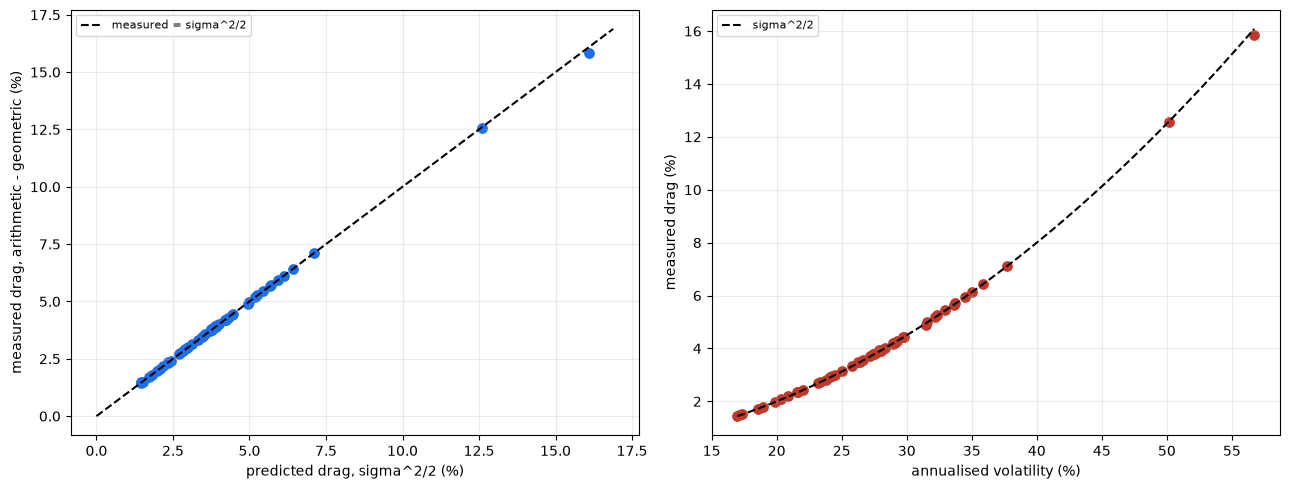

correlation between measured and predicted: 0.9999
      arithmetic  log_growth  geometric    vol  measured_drag  predicted_drag     n
name                                                                               
AMD       0.4071      0.2487     0.2824 0.5671         0.1584          0.1608  4146
MU        0.4109      0.2852     0.3300 0.5017         0.1257          0.1258  4146
INTC      0.2129      0.1419     0.1525 0.3773         0.0710          0.0712  4146
BA        0.1614      0.0971     0.1020 0.3584         0.0643          0.0642  4146
QCOM      0.1696      0.1084     0.1145 0.3501         0.0612          0.0613  4146
F         0.1195      0.0602     0.0620 0.3445         0.0593          0.0593  4146
C         0.1619      0.1047     0.1104 0.3375         0.0572          0.0569  4146
MS        0.1944      0.1379     0.1478 0.3366         0.0565          0.0566  4146


In [4]:
dt = st.drag_table(R)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(dt["predicted_drag"] * 100, dt["measured_drag"] * 100, s=45,
                color="#1f6feb")
lim = [0, max(dt[["predicted_drag", "measured_drag"]].max()) * 105]
axes[0].plot(lim, lim, "k--", lw=1.5, label="measured = sigma^2/2")
axes[0].set_xlabel("predicted drag, sigma^2/2 (%)")
axes[0].set_ylabel("measured drag, arithmetic - geometric (%)")
axes[0].legend(fontsize=8)
axes[1].scatter(dt["vol"] * 100, dt["measured_drag"] * 100, s=45, color="#c0392b")
xs = np.linspace(dt["vol"].min(), dt["vol"].max(), 50)
axes[1].plot(xs * 100, xs ** 2 / 2 * 100, "k--", lw=1.5, label="sigma^2/2")
axes[1].set_xlabel("annualised volatility (%)")
axes[1].set_ylabel("measured drag (%)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"correlation between measured and predicted: "
      f"{dt['measured_drag'].corr(dt['predicted_drag']):.4f}")
print(dt.sort_values("vol", ascending=False).head(8).round(4).to_string())

> \U0001F4A1 **In plain words.** The points sit on the line. The gap between what a stock
> averages and what it compounds at is not a mystery to be explained — it is σ²/2, and it can
> be computed before looking at any outcome.

### 3.2 The horizon paradox

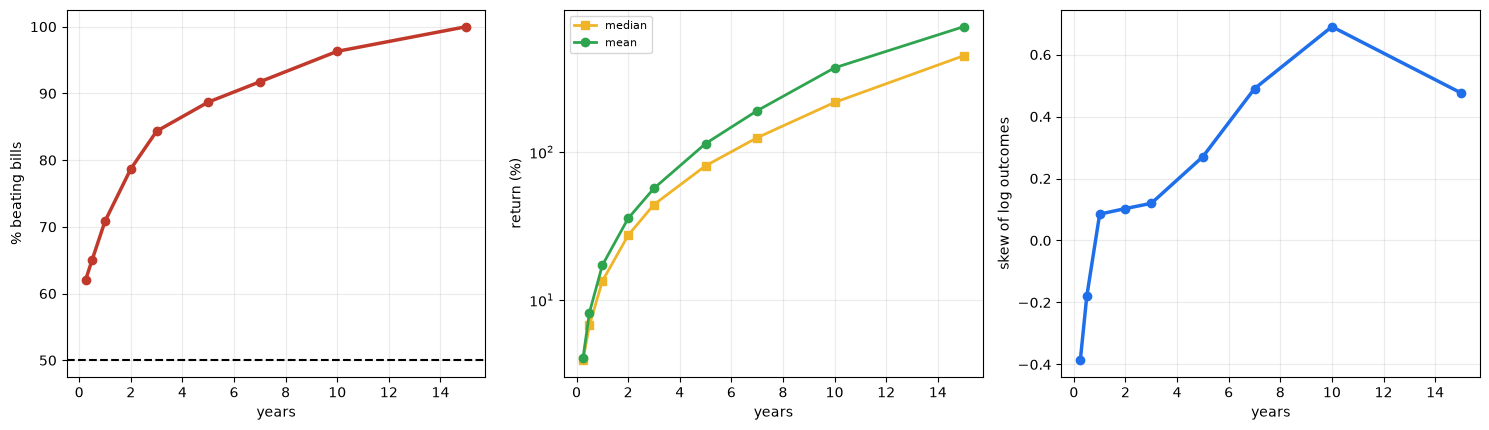

            n  share_beat_cash  share_lost_money  median_return  mean_return    skew
years                                                                               
0.2500   3250           0.6206            0.3723         0.0391       0.0404 -0.3865
0.5000   3200           0.6503            0.3366         0.0674       0.0822 -0.1803
1.0000   3100           0.7084            0.2684         0.1340       0.1714  0.0851
2.0000   2900           0.7869            0.1886         0.2734       0.3556  0.1031
3.0000   2700           0.8433            0.1385         0.4409       0.5674  0.1199
5.0000   2300           0.8870            0.0935         0.8058       1.1384  0.2706
7.0000   1900           0.9174            0.0616         1.2480       1.8986  0.4900
10.0000  1300           0.9631            0.0246         2.1603       3.6993  0.6900
15.0000   300           1.0000            0.0000         4.4637       7.0134  0.4763


In [5]:
sw = st.horizon_sweep(R, cash, horizons_years=(0.25, 0.5, 1, 2, 3, 5, 7, 10, 15))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(sw.index, sw["share_beat_cash"] * 100, "o-", lw=2.5, color="#c0392b")
axes[0].axhline(50, color="k", ls="--", lw=1.5)
axes[0].set_xlabel("years"); axes[0].set_ylabel("% beating bills")
axes[1].plot(sw.index, sw["median_return"] * 100, "s-", lw=2, color="#f0b429",
             label="median")
axes[1].plot(sw.index, sw["mean_return"] * 100, "o-", lw=2, color="#2ea44f",
             label="mean")
axes[1].set_xlabel("years"); axes[1].set_ylabel("return (%)"); axes[1].legend(fontsize=8)
axes[1].set_yscale("symlog")
axes[2].plot(sw.index, sw["skew"], "o-", lw=2.5, color="#1f6feb")
axes[2].set_xlabel("years"); axes[2].set_ylabel("skew of log outcomes")
plt.tight_layout(); plt.show()
print(sw[["n", "share_beat_cash", "share_lost_money", "median_return", "mean_return",
          "skew"]].round(4).to_string())

### 3.2b The breakeven condition, and where each name sits

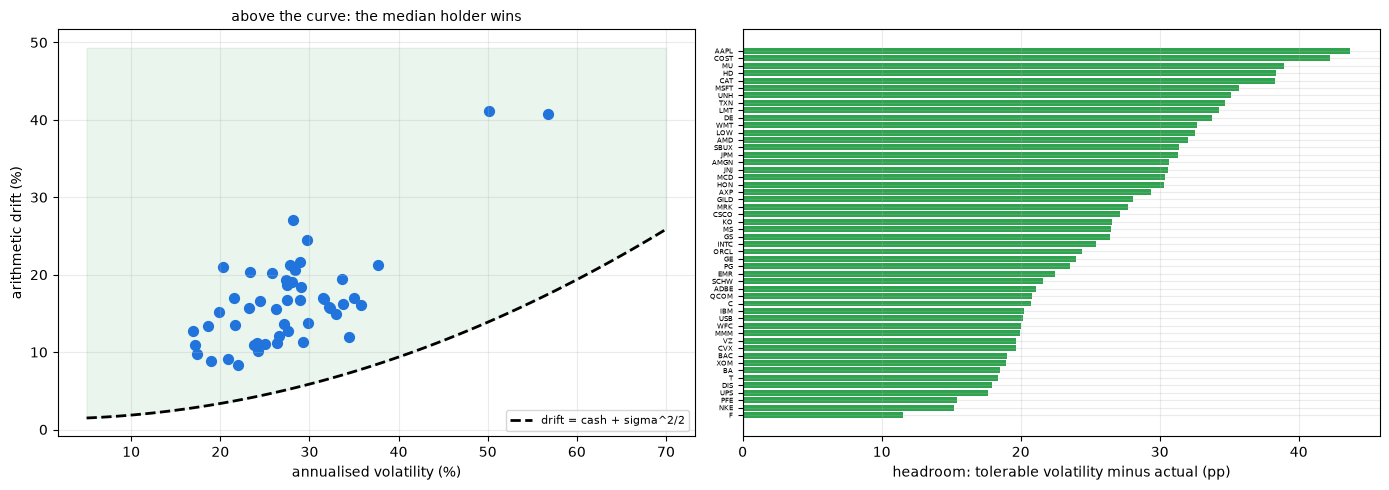

{'cash_log_growth': 0.0136, 'share_above_threshold': 0.0, 'median_headroom': 0.2645, 'mean_drift': 0.1668, 'mean_vol': 0.2784, 'mean_breakeven': 0.5434}
      drift    vol  breakeven_vol  headroom  log_growth  cash_log_growth  median_beats_cash
name                                                                                       
F    0.1195 0.3445         0.4601    0.1156      0.0602           0.0136               True
NKE  0.1126 0.2926         0.4448    0.1522      0.0696           0.0136               True
PFE  0.0837 0.2204         0.3744    0.1540      0.0595           0.0136               True
UPS  0.1014 0.2428         0.4190    0.1763      0.0719           0.0136               True
DIS  0.1118 0.2638         0.4432    0.1794      0.0771           0.0136               True
T    0.0907 0.2090         0.3927    0.1836      0.0688           0.0136               True
BA   0.1614 0.3584         0.5437    0.1853      0.0971           0.0136               True
XOM  0.1102 0.2502 

In [6]:
cond = st.median_beats_cash_condition(R, cash)
tab = cond["table"].sort_values("headroom")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(tab["vol"] * 100, tab["drift"] * 100, s=50, color="#1f6feb")
vols = np.linspace(0.05, max(tab["vol"].max() * 1.2, 0.7), 120)
axes[0].plot(vols * 100, (cond["cash_log_growth"] + vols ** 2 / 2) * 100, "k--", lw=2,
             label="drift = cash + sigma^2/2")
axes[0].fill_between(vols * 100, (cond["cash_log_growth"] + vols ** 2 / 2) * 100,
                     max(tab["drift"].max() * 120, 40), alpha=0.10, color="#2ea44f")
axes[0].set_xlabel("annualised volatility (%)")
axes[0].set_ylabel("arithmetic drift (%)"); axes[0].legend(fontsize=8)
axes[0].set_title("above the curve: the median holder wins", fontsize=10)
colors = ["#c0392b" if hh < 0 else "#2ea44f" for hh in tab["headroom"]]
axes[1].barh(range(len(tab)), tab["headroom"] * 100, color=colors)
axes[1].axvline(0, color="k", lw=1.5)
axes[1].set_yticks(range(len(tab)))
axes[1].set_yticklabels(tab.index, fontsize=5)
axes[1].set_xlabel("headroom: tolerable volatility minus actual (pp)")
plt.tight_layout(); plt.show()
print({k: round(v, 4) for k, v in cond.items() if k != "table"})
print(tab.head(8).round(4).to_string())

> \U0001F4A1 **In plain words.** The curve in the left panel is the whole result. A stock is
> above it — median holder wins — when its drift exceeds cash plus half its variance. The
> quadratic is why volatility matters so disproportionately: doubling σ quadruples the drift you
> need to stay above the line. Bessembinder's small caps and delisting candidates fail on both
> terms at once.

### 3.3 Dollar wealth concentration

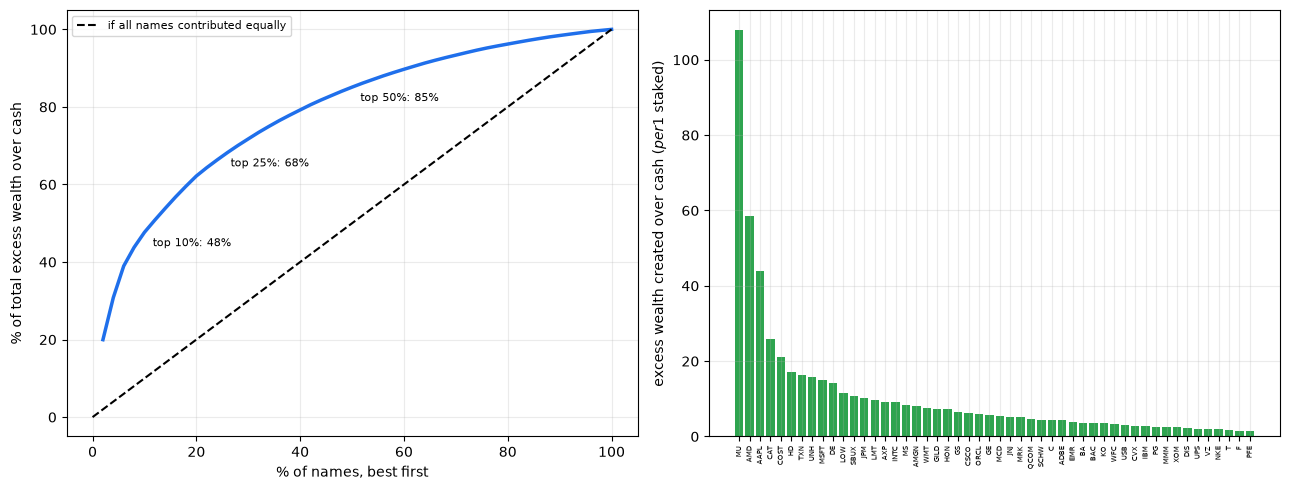

{'n_names': 50, 'cash_return': 0.2512, 'total_excess': 539.9174, 'share_beat_cash': 1.0, 'share_lost_money': 0.0, 'median_terminal': 5.8649, 'mean_terminal': 11.0496, 'best_name': 'MU', 'best_excess': 107.8307, 'top_2pct_share': 0.1997, 'top_5pct_share': 0.3897, 'top_10pct_share': 0.4766, 'top_25pct_share': 0.6824, 'top_50pct_share': 0.851, 'n_names_for_all': 50, 'share_of_names_for_all': 1.0}


In [7]:
wc = st.wealth_concentration(R, cash)
ranked = wc["ranked"]
cum = ranked.cumsum() / ranked.sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum * 100, lw=2.5,
             color="#1f6feb")
axes[0].plot([0, 100], [0, 100], "k--", lw=1.5, label="if all names contributed equally")
for p in (10, 25, 50):
    k = max(int(np.ceil(len(ranked) * p / 100)), 1)
    axes[0].annotate(f"top {p}%: {cum.iloc[k-1]:.0%}", (p, cum.iloc[k-1] * 100),
                     fontsize=8, xytext=(6, -10), textcoords="offset points")
axes[0].set_xlabel("% of names, best first")
axes[0].set_ylabel("% of total excess wealth over cash"); axes[0].legend(fontsize=8)
axes[1].bar(range(len(ranked)), ranked,
            color=["#2ea44f" if v > 0 else "#c0392b" for v in ranked])
axes[1].set_xticks(range(len(ranked)))
axes[1].set_xticklabels(ranked.index, rotation=90, fontsize=5)
axes[1].set_ylabel("excess wealth created over cash ($ per $1 staked)")
plt.tight_layout(); plt.show()
print({k: (round(v, 4) if isinstance(v, (int, float)) else v)
       for k, v in wc.items() if k != "ranked"})

### 3.4 The reconciliation, decomposed

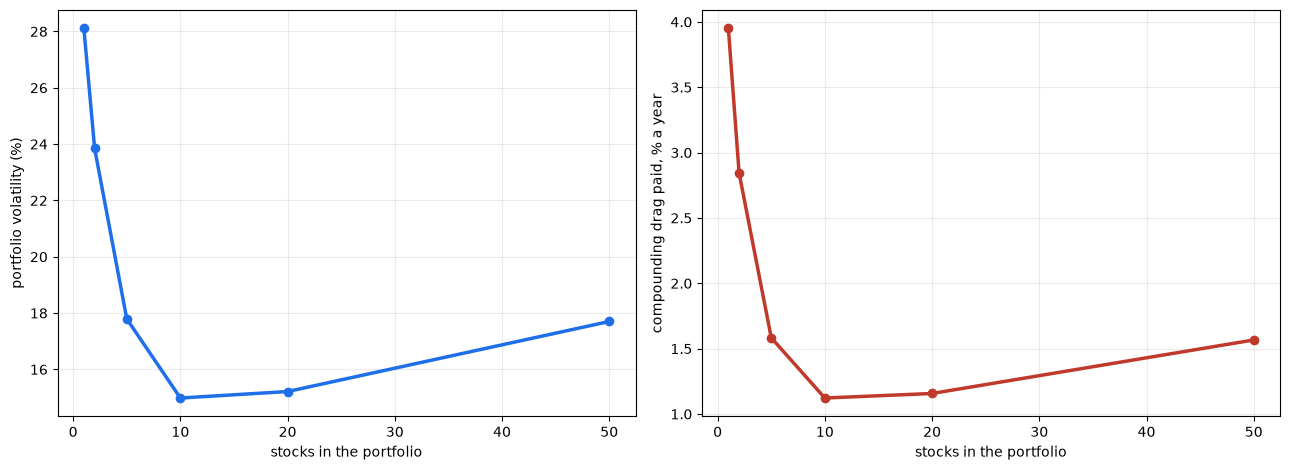

                             value
cash                        0.2512
median single name          5.8649
buy and hold basket        11.0496
rebalanced equal weight    11.0077
single-name vol             0.2784
portfolio vol               0.1770
drag saved per year         0.0231
compounded over the sample  0.4555


In [8]:
rec = st.index_reconciliation(R, cash)
years = len(R) / 252
rows = []
for k in (1, 2, 5, 10, 20, 50):
    sub = R.iloc[:, :min(k, R.shape[1])]
    eq = sub.mean(axis=1)
    rows.append({"n": min(k, R.shape[1]),
                 "portfolio vol": eq.std(ddof=1) * np.sqrt(252),
                 "drag": st.variance_drag(0, eq.std(ddof=1) * np.sqrt(252))})
d = pd.DataFrame(rows).set_index("n")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(d.index, d["portfolio vol"] * 100, "o-", lw=2.5, color="#1f6feb")
axes[0].set_xlabel("stocks in the portfolio")
axes[0].set_ylabel("portfolio volatility (%)")
axes[1].plot(d.index, d["drag"] * 100, "o-", lw=2.5, color="#c0392b")
axes[1].set_xlabel("stocks in the portfolio")
axes[1].set_ylabel("compounding drag paid, % a year")
plt.tight_layout(); plt.show()
print(pd.DataFrame({
    "cash": [rec["cash"]], "median single name": [rec["median_single"]],
    "buy and hold basket": [rec["buy_and_hold_basket"]],
    "rebalanced equal weight": [rec["rebalanced_equal_weight"]],
    "single-name vol": [rec["single_vol"]], "portfolio vol": [rec["portfolio_vol"]],
    "drag saved per year": [rec["drag_saved"]],
    "compounded over the sample": [np.expm1(np.log1p(rec["drag_saved"]) * years)],
}).T.rename(columns={0: "value"}).round(4).to_string())

> \U0001F4A1 **In plain words.** Both panels are the same curve, because drag is variance over
> two. Whatever diversification does to the left-hand chart, it does quadratically to the
> right-hand one — which is why the first few names matter so much.

### 3.5 Rebalancing, and what happens without it

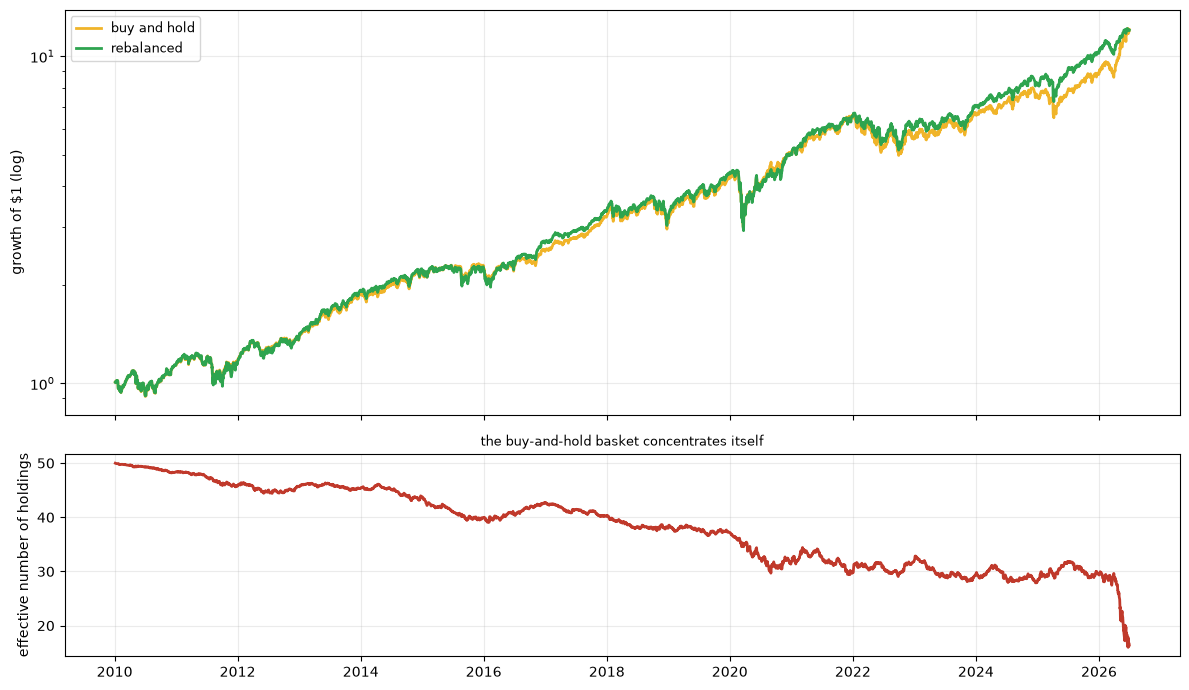

            buy_and_hold  rebalanced  max_weight  top5_weight  effective_n
date                                                                      
2010-01-05        1.0065      1.0065      0.0212       0.1034      49.9871
2018-04-02        3.1343      3.2190      0.0497       0.2173      39.1229
2026-06-30       12.0496     12.0077      0.1811       0.4375      16.3986


In [9]:
bh = st.buy_and_hold_index(R)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(bh.index, bh["buy_and_hold"], lw=2, color="#f0b429", label="buy and hold")
axes[0].plot(bh.index, bh["rebalanced"], lw=2, color="#2ea44f", label="rebalanced")
axes[0].set_yscale("log"); axes[0].set_ylabel("growth of $1 (log)")
axes[0].legend(fontsize=9)
axes[1].plot(bh.index, bh["effective_n"], lw=2, color="#c0392b")
axes[1].set_ylabel("effective number of holdings")
axes[1].set_title("the buy-and-hold basket concentrates itself", fontsize=9)
plt.tight_layout(); plt.show()
print(bh.iloc[[0, len(bh)//2, -1]].round(4).to_string())

### 3.6 The odds for a concentrated book

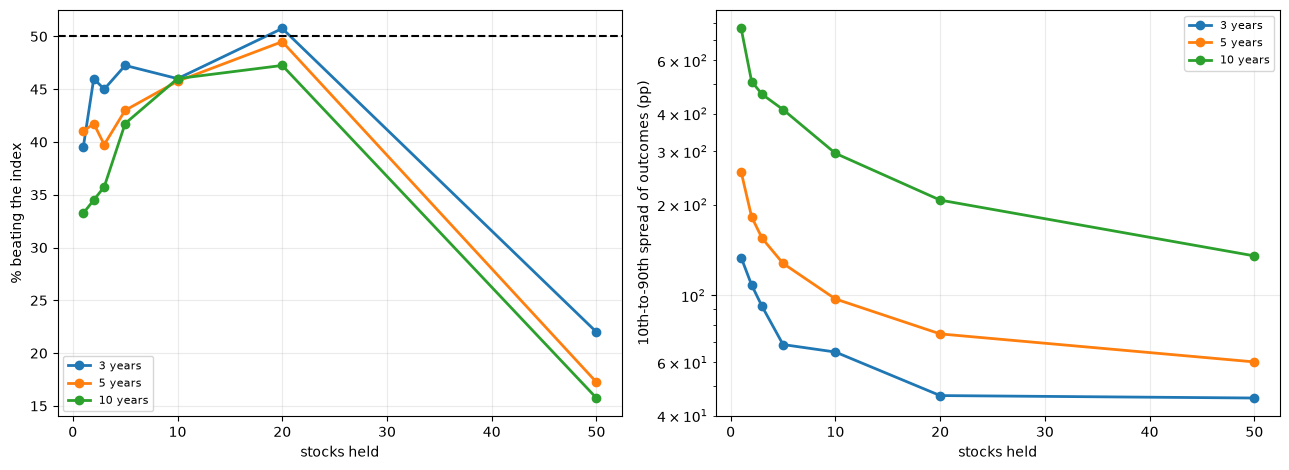

horizon      3      5      10
n_stocks                     
1        0.3950 0.4100 0.3320
2        0.4600 0.4180 0.3450
3        0.4500 0.3980 0.3580
5        0.4720 0.4300 0.4180
10       0.4600 0.4580 0.4600
20       0.5070 0.4950 0.4720
50       0.2200 0.1720 0.1580


In [10]:
rows = []
for hy in (3, 5, 10):
    o = st.concentrated_portfolio_odds(R, cash, sizes=(1, 2, 3, 5, 10, 20, 50),
                                       horizon_years=hy, n_draws=400)
    for n, r in o.iterrows():
        rows.append({"horizon": hy, "n_stocks": n, **r.to_dict()})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for hy, g in d.groupby("horizon"):
    axes[0].plot(g["n_stocks"], g["share_beat_index"] * 100, "o-", lw=2,
                 label=f"{hy} years")
    axes[1].plot(g["n_stocks"], (g["p90"] - g["p10"]) * 100, "o-", lw=2,
                 label=f"{hy} years")
axes[0].axhline(50, color="k", ls="--", lw=1.5)
axes[0].set_xlabel("stocks held"); axes[0].set_ylabel("% beating the index")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("stocks held")
axes[1].set_ylabel("10th-to-90th spread of outcomes (pp)")
axes[1].set_yscale("log"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.pivot(index="n_stocks", columns="horizon",
              values="share_beat_index").round(3).to_string())

### 3.7 Survivorship, quantified

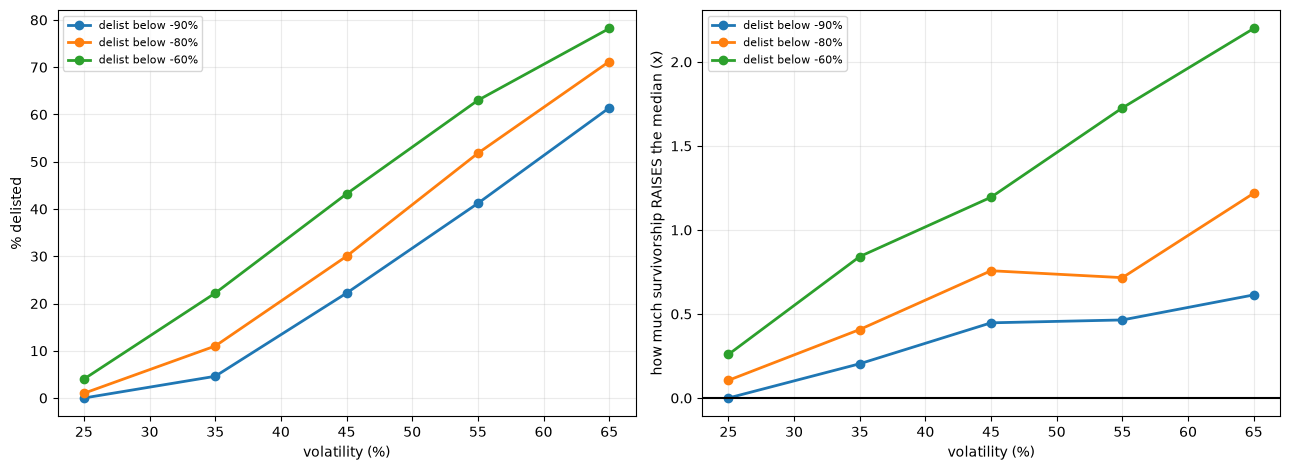

   vol  delist_at  n_all  n_survived  delist_rate  median_all  median_survivors  share_negative_all  share_negative_survivors   bias
0.2500    -0.6000    500         480       0.0400      1.9548            2.2139              0.1840                    0.1500 0.2591
0.2500    -0.8000    500         495       0.0100      1.9548            2.0600              0.1840                    0.1758 0.1052
0.2500    -0.9000    500         500       0.0000      1.9548            1.9548              0.1840                    0.1840 0.0000
0.3500    -0.6000    500         389       0.2220      0.4436            1.2852              0.4060                    0.2365 0.8416
0.3500    -0.8000    500         445       0.1100      0.4436            0.8512              0.4060                    0.3326 0.4075
0.3500    -0.9000    500         477       0.0460      0.4436            0.6475              0.4060                    0.3774 0.2039
0.4500    -0.6000    500         284       0.4320     -0.4441        

In [11]:
rows = []
for vol in (0.25, 0.35, 0.45, 0.55, 0.65):
    for cut in (-0.60, -0.80, -0.90):
        s = st.survivorship_experiment(n_stocks=500, n_days=6000, vol=vol,
                                       delist_at=cut)
        rows.append({"vol": vol, "delist_at": cut, **s})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for cut, g in d.groupby("delist_at"):
    axes[0].plot(g["vol"] * 100, g["delist_rate"] * 100, "o-", lw=2,
                 label=f"delist below {cut:.0%}")
    axes[1].plot(g["vol"] * 100, g["bias"], "o-", lw=2, label=f"delist below {cut:.0%}")
axes[0].set_xlabel("volatility (%)"); axes[0].set_ylabel("% delisted")
axes[0].legend(fontsize=8)
axes[1].axhline(0, color="k", lw=1.5)
axes[1].set_xlabel("volatility (%)")
axes[1].set_ylabel("how much survivorship RAISES the median (x)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.round(4).to_string(index=False))

> \U0001F4A1 **In plain words.** Every bar is positive, so restricting to survivors flatters the
> median. This study's basket is all survivors, and it *still* shows the effect — which is a
> stronger position than replicating the number on a survivorship-free universe would be.

### 3.8 The control — the whole result from one parameter

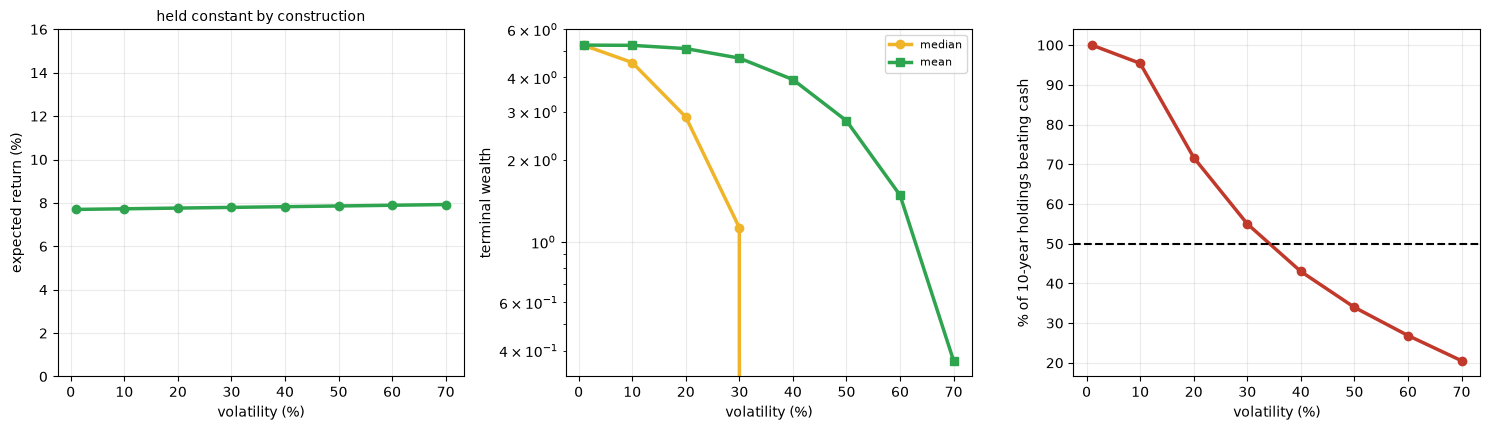

        arith  median   mean  share_beat  predicted_drag
vol                                                     
0.0100 0.0770  5.2402 5.2531      1.0000          0.0000
0.1000 0.0773  4.5366 5.2431      0.9541          0.0050
0.2000 0.0776  2.8662 5.1018      0.7169          0.0200
0.3000 0.0779  1.1277 4.7082      0.5499          0.0450
0.4000 0.0783 -0.0771 3.9286      0.4300          0.0800
0.5000 0.0786 -0.6845 2.7756      0.3397          0.1250
0.6000 0.0789 -0.9150 1.4822      0.2687          0.1800
0.7000 0.0793 -0.9820 0.3671      0.2053          0.2450


In [12]:
rows = []
for vol in (0.01, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70):
    sim = st.synthetic_cross_section(n_stocks=500, n_days=6000, drift=0.08, vol=vol)
    f = np.expm1(np.log1p(sim).sum())
    simcash = pd.Series(np.full(len(sim), 0.02 / 252), index=sim.index)
    sws = st.horizon_sweep(sim, simcash, horizons_years=(10,), step=252)
    rows.append({"vol": vol, "arith": sim.mean().mean() * 252,
                 "median": f.median(), "mean": f.mean(),
                 "share_beat": sws.loc[10, "share_beat_cash"],
                 "predicted_drag": st.variance_drag(0, vol)})
d = pd.DataFrame(rows).set_index("vol")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(d.index * 100, d["arith"] * 100, "o-", lw=2.5, color="#2ea44f")
axes[0].set_ylim(0, 16)
axes[0].set_xlabel("volatility (%)"); axes[0].set_ylabel("expected return (%)")
axes[0].set_title("held constant by construction", fontsize=10)
axes[1].plot(d.index * 100, d["median"], "o-", lw=2.5, color="#f0b429", label="median")
axes[1].plot(d.index * 100, d["mean"], "s-", lw=2.5, color="#2ea44f", label="mean")
axes[1].set_yscale("log")
axes[1].set_xlabel("volatility (%)"); axes[1].set_ylabel("terminal wealth")
axes[1].legend(fontsize=8)
axes[2].plot(d.index * 100, d["share_beat"] * 100, "o-", lw=2.5, color="#c0392b")
axes[2].axhline(50, color="k", ls="--", lw=1.5)
axes[2].set_xlabel("volatility (%)")
axes[2].set_ylabel("% of 10-year holdings beating cash")
plt.tight_layout(); plt.show()
print(d.round(4).to_string())

> \U0001F4A1 **In plain words.** The left panel is flat: expected return never changes. The
> right panel falls from nearly 100% to well under half. Bessembinder's headline needs no
> economics at all — only compounding and a volatility number.

## 4 · The verdict

In [13]:
dt = st.drag_table(R)
sw = st.horizon_sweep(R, cash, horizons_years=(1, 10))
wc = st.wealth_concentration(R, cash)
rec = st.index_reconciliation(R, cash)
odds = st.concentrated_portfolio_odds(R, cash, sizes=(5, 20, 50), horizon_years=10,
                                      n_draws=400)
pd.DataFrame({
    "names (all survivors)": [R.shape[1]],
    "measured drag, mean": [dt["measured_drag"].mean()],
    "predicted drag, sigma^2/2": [dt["predicted_drag"].mean()],
    "% of 1-year holdings beating bills": [sw.loc[1, "share_beat_cash"]],
    "% of 10-year holdings beating bills": [sw.loc[10, "share_beat_cash"]],
    "mean return, 1 year": [sw.loc[1, "mean_return"]],
    "mean return, 10 years": [sw.loc[10, "mean_return"]],
    "top 10% of names' share of excess wealth": [wc["top_10pct_share"]],
    "names that lost money outright": [wc["share_lost_money"]],
    "median single name": [rec["median_single"]],
    "rebalanced equal weight": [rec["rebalanced_equal_weight"]],
    "drag saved by diversifying, per year": [rec["drag_saved"]],
    "5-stock book beats the index": [odds.loc[5, "share_beat_index"]],
    "50-stock book beats the index": [odds.loc[50, "share_beat_index"]],
}).T.rename(columns={0: "value"}).round(4)

,value
names (all survivors),50.0000
"measured drag, mean",0.0414
"predicted drag, sigma^2/2",0.0414
% of 1-year holdings beating bills,0.7084
% of 10-year holdings beating bills,0.9631
"mean return, 1 year",0.1714
"mean return, 10 years",3.6993
top 10% of names' share of excess wealth,0.4766
names that lost money outright,0.0000
median single name,5.8649


## 5 · Going further

- **Run it on a survivorship-free universe.** CRSP with delisted names is the proper sample;
  §3.7 predicts the effect gets larger, and by roughly how much.
- **Fernholz's stochastic portfolio theory** formalises §3.4: the excess growth rate of a
  rebalanced portfolio over its constituents is exactly half the difference between the average
  constituent variance and the portfolio variance. Deriving it and checking it numerically here
  would be a clean addition.
- **Barberis & Huang (2008) is the counterargument worth taking seriously.** An investor with
  probability weighting may *rationally* prefer the median-losing, tail-winning bet. The finding
  is arithmetic; whether it is a mistake to accept it is a preference question.
- **The size dimension.** Small caps have far higher σ and therefore far more drag, which is
  part of why the small-cap premium is so much weaker in geometric terms than in arithmetic
  ones — a comparison **1004** sets up and this study could complete.